c:\Users\user\anaconda3\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImplicitPNASolver 검증 시작
구조: 1 section, 3 parts (Outer / Reinf / Inner), 30 nodes

데이터: nodes=torch.Size([30, 8]) | edges=torch.Size([2, 54])

[ Section 2-A ] Forward Validation
  Solver Mp   :     585,000.00 N·mm
  Manual Mp   :     585,000.00 N·mm
  PNA y       :        40.0000 mm
  Abs Error   :         0.0000 N·mm  ->  PASS

[ Section 2-B ] Backward Validation (IFT vs Finite Difference)
    Node |   Autograd (IFT) |    Finite Diff |   RelErr
  -------+------------------+----------------+---------
      12 |        1531.9149 |         0.0014 | 109658631.623% FAIL
      25 |       -2680.8511 |     -1799.9948 |  48.937% FAIL
      24 |       -2680.8511 |     -1799.9948 |  48.937% FAIL
      13 |        1531.9149 |         0.0014 | 109658631.623% FAIL
      14 |        1531.9149 |         0.0014 | 109658631.623% FAIL
      26 |       -2680.8511 |     -1799.9948 |  48.937% FAIL

  평균 상대 오차: 54829340.2796%  ->  FAIL

[ Section 2-C ] Training  |  Target Mp = 1,800,000 N·mm  |  Epochs: 300


C:\Users\user\AppData\Local\Temp\ipykernel_11096\542658367.py:448: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_11096\542658367.py:448: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_11096\542658367.py:448: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_11096\542658367.py:448: UserWarning: Glyph 47156 (\N{HANGUL SYLLABLE RYEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_11096\542658367.py:448: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_11096\542658367.py:448: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from fo

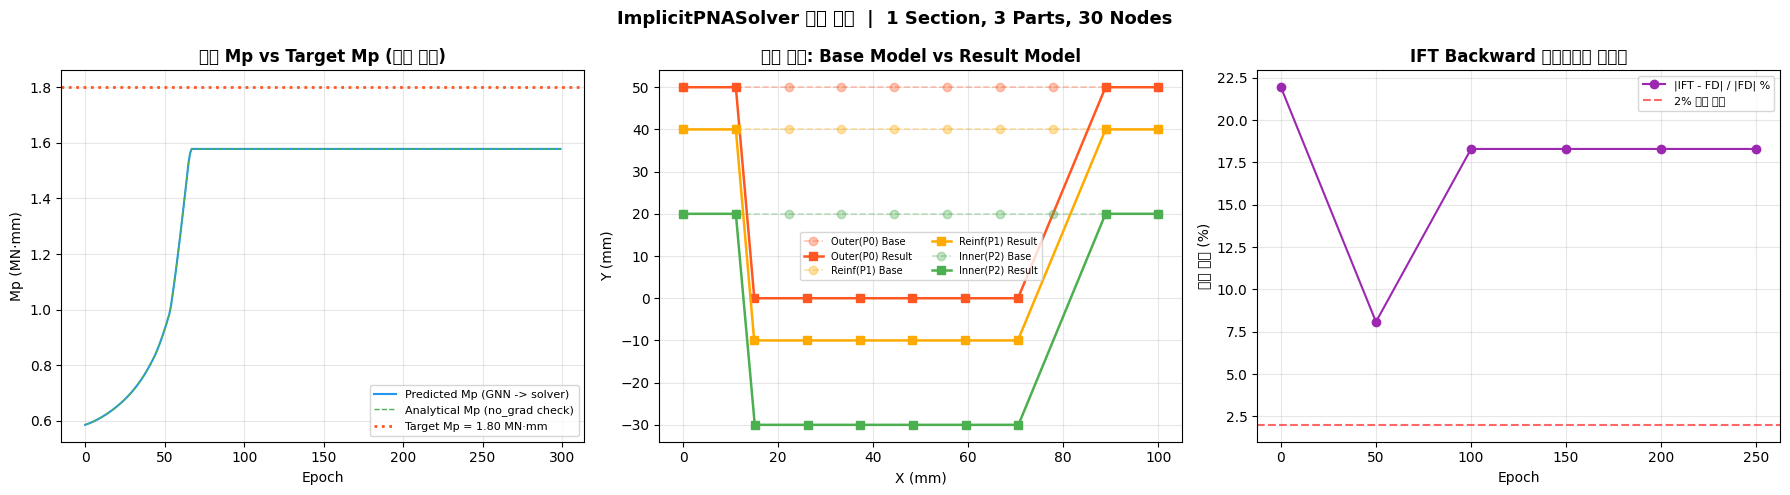


결과 저장: docs/validate_pna_result.png

최종 결과 요약
  Initial Mp :        585,471 N·mm
  Final Mp   :      1,578,000 N·mm
  Target Mp  :      1,800,000 N·mm
  최종 오차  :  12.33%


In [1]:
#!/usr/bin/env python
# coding: utf-8
"""
ImplicitPNASolver Validation Code
──────────────────────────────────
Synod design deliberation 결과 반영:
  - 1 section, 3 parts (Outer/Reinf/Inner), 30 nodes
  - Section 1: Data Setup + SimpleCGDN 모델
  - Section 2: Forward/Backward 검증 (IFT vs FD) + Training Loop
  - Section 3: 시각화 (Mp 수렴 + Base vs Result 단면 비교 + 그래디언트 오차)

3가지 Mp 구분:
  pred_mp       - GNN 변형 후 solver 계산값 (gradient 포함, 학습 목표)
  target_mp     - 고정 설계 목표값 (외부 지정)
  analytical_mp - no_grad 로 solver 재계산 (forward 정확도 추적용)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# ImplicitPNASolver (from 20260312_v2.py — unchanged)
# ══════════════════════════════════════════════════════════════════

class ImplicitPNASolver(torch.autograd.Function):
    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=30):
        with torch.no_grad():
            y = coords[:, 1]
            t_flat = t.squeeze(-1)
            fy_flat = fy.squeeze(-1)
            y_lo = y.min().clone()
            y_hi = y.max().clone()
            for _ in range(n_iter):
                y_mid = 0.5 * (y_lo + y_hi)
                F_tens = torch.sum(t_flat * fy_flat * (y > y_mid).float())
                F_comp = torch.sum(t_flat * fy_flat * (y < y_mid).float())
                if F_tens > F_comp:
                    y_lo = y_mid
                else:
                    y_hi = y_mid
            y_pna = 0.5 * (y_lo + y_hi)
        d = torch.abs(coords[:, 1] - y_pna)
        t_flat = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)
        mp_pred = torch.sum(t_flat * fy_flat * d)
        ei = edge_index if edge_index is not None else torch.zeros(0, dtype=torch.long)
        ctx.save_for_backward(coords, t, fy, y_pna.unsqueeze(0), ei)
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        coords, t, fy, y_pna_buf, _ = ctx.saved_tensors
        y_pna = y_pna_buf.squeeze(0)
        y = coords[:, 1]
        t_flat = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)
        s = torch.sign(y - y_pna)
        dg_dy_pna = -torch.sum(t_flat * fy_flat)
        dg_dy = t_flat * fy_flat
        dy_pna_dy = -dg_dy / (dg_dy_pna + 1e-12)
        direct   = t_flat * fy_flat * s
        indirect = -torch.sum(t_flat * fy_flat * s) * dy_pna_dy
        dMp_dy   = direct + indirect
        grad_coords = torch.zeros_like(coords)
        grad_coords[:, 1] = grad_output * dMp_dy
        return grad_coords, None, None, None, None


def calculate_mpl(coords, t, fy, edge_index):
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)


# ══════════════════════════════════════════════════════════════════
# SECTION 1: Data Setup (1 section, 3 parts, 30 nodes)
# ══════════════════════════════════════════════════════════════════

def build_simple_section():
    """
    1 section (section_id=0), 3 parts:
      Part 0 (Outer): y=50, t=1.5, fy=1500
      Part 1 (Reinf): y=40, t=2.0, fy=1500
      Part 2 (Inner): y=20, t=1.5, fy=1200
    Fixed nodes: i=0,1,8,9  ->  fix_x=fix_y=1
    Node features: [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    """
    part_configs = [
        (0, 50.0, 1.5, 1500.0),
        (1, 40.0, 2.0, 1500.0),
        (2, 20.0, 1.5, 1200.0),
    ]
    nodes = []
    node_registry = {}
    idx = 0
    for part_id, y_coord, t_val, fy_val in part_configs:
        for i in range(10):
            x_coord = i * (100.0 / 9.0)
            fix = 1.0 if i in [0, 1, 8, 9] else 0.0
            nodes.append([x_coord, y_coord, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, i)] = idx
            idx += 1

    x = torch.tensor(nodes, dtype=torch.float32)

    src_list, dst_list, edge_attr_list = [], [], []

    def add_edge(u, v, part_id):
        dx = x[v, 0] - x[u, 0]
        dy = x[v, 1] - x[u, 1]
        length = math.sqrt(dx**2 + dy**2)
        angle = math.atan2(dy, dx)
        src_list.extend([u, v])
        dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0],
                                [length, -angle, float(part_id), 0.0]])

    for part_id, _, _, _ in part_configs:
        for i in range(9):
            u = node_registry[(part_id, i)]
            v = node_registry[(part_id, i + 1)]
            add_edge(u, v, part_id)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr), node_registry


# ── SimpleCGDN (경량 버전, 검증용) ──

class FiLMGenerator(nn.Module):
    MP_SCALE = 1e6

    def __init__(self, hidden):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.GELU(), nn.Linear(32, hidden * 2))
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        out = self.net(target_mp / self.MP_SCALE)
        dg, beta = torch.chunk(out, 2, dim=-1)
        return 1.0 + dg, beta


class CGDNBlock(nn.Module):
    def __init__(self, hidden, heads=2, edge_dim=4):
        super().__init__()
        self.conv = GATv2Conv(hidden, hidden // heads, heads=heads,
                              edge_dim=edge_dim, concat=True)
        self.norm = LayerNorm(hidden)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)
        h = gamma * h + beta
        h = F.gelu(h)
        return h + h_res


class SimpleCGDN(nn.Module):
    def __init__(self, in_channels=8, hidden=64, num_layers=2, heads=2, max_disp=50.0):
        super().__init__()
        self.max_disp = max_disp
        self.encoder  = nn.Sequential(nn.Linear(in_channels, hidden), LayerNorm(hidden), nn.GELU())
        self.films    = nn.ModuleList([FiLMGenerator(hidden) for _ in range(num_layers)])
        self.blocks   = nn.ModuleList([CGDNBlock(hidden, heads) for _ in range(num_layers)])
        self.decoder  = nn.Sequential(nn.Linear(hidden, 32), nn.GELU(), nn.Linear(32, 2))

    def forward(self, x, edge_index, edge_attr, target_mp, fix_x_mask, fix_y_mask):
        h = self.encoder(x)
        for film, block in zip(self.films, self.blocks):
            gamma, beta = film(target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)
        delta = torch.clamp(self.decoder(h), -self.max_disp, self.max_disp)
        delta_x = delta[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta[:, 1:2] * (~fix_y_mask).float()
        delta = torch.cat([delta_x, delta_y], dim=1)
        return x[:, :2] + delta, delta


# ══════════════════════════════════════════════════════════════════
# SECTION 2-A: Forward 정확성 검증
# ══════════════════════════════════════════════════════════════════

def validate_forward(data):
    """
    ImplicitPNASolver.forward 출력 vs 수동 bisection 계산 비교.
    허용 오차: 절대값 1 N·mm 미만.
    """
    print("\n" + "=" * 60)
    print("[ Section 2-A ] Forward Validation")
    print("=" * 60)

    coords = data.x[:, :2].clone()
    t      = data.x[:, 6:7].clone()
    fy     = data.x[:, 7:8].clone()

    mp_solver = calculate_mpl(coords, t, fy, None)

    with torch.no_grad():
        y_flat  = coords[:, 1]
        t_flat  = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)
        y_lo = y_flat.min().clone()
        y_hi = y_flat.max().clone()
        for _ in range(50):
            y_mid  = 0.5 * (y_lo + y_hi)
            F_tens = torch.sum(t_flat * fy_flat * (y_flat > y_mid).float())
            F_comp = torch.sum(t_flat * fy_flat * (y_flat < y_mid).float())
            if F_tens > F_comp:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna_ref = 0.5 * (y_lo + y_hi)
        mp_ref = torch.sum(t_flat * fy_flat * torch.abs(y_flat - y_pna_ref))

    err = abs(mp_solver.item() - mp_ref.item())
    print(f"  Solver Mp   : {mp_solver.item():>14,.2f} N·mm")
    print(f"  Manual Mp   : {mp_ref.item():>14,.2f} N·mm")
    print(f"  PNA y       : {y_pna_ref.item():>14.4f} mm")
    print(f"  Abs Error   : {err:>14.4f} N·mm  ->  {'PASS' if err < 1.0 else 'FAIL'}")
    return mp_solver.item(), mp_ref.item()


# ══════════════════════════════════════════════════════════════════
# SECTION 2-B: Backward 정확성 검증 (IFT vs Finite Difference)
# ══════════════════════════════════════════════════════════════════

def validate_backward(data, n_check=6, eps=1e-2):
    """
    IFT backward 그래디언트 vs 중앙 유한차분 비교.
    자유 노드(fix_y=False)의 y좌표를 eps 만큼 perturbation.
    허용 상대 오차: 2% 미만.
    """
    print("\n" + "=" * 60)
    print("[ Section 2-B ] Backward Validation (IFT vs Finite Difference)")
    print("=" * 60)

    coords = data.x[:, :2].clone().double()
    t      = data.x[:, 6:7].clone().double()
    fy     = data.x[:, 7:8].clone().double()
    fix_y  = data.x[:, 3].bool()
    free_indices = (~fix_y).nonzero(as_tuple=True)[0]

    perm   = torch.randperm(len(free_indices))[:n_check]
    chosen = free_indices[perm]

    # Autograd 그래디언트
    coords_ag = coords.clone().requires_grad_(True)
    mp = calculate_mpl(coords_ag, t, fy, None)
    mp.backward()
    ag_grads = coords_ag.grad[:, 1].detach()

    errors = []
    print(f"  {'Node':>6} | {'Autograd (IFT)':>16} | {'Finite Diff':>14} | {'RelErr':>8}")
    print(f"  {'-'*6}-+-{'-'*16}-+-{'-'*14}-+-{'-'*8}")

    for idx in chosen:
        idx = idx.item()
        c_plus  = coords.clone(); c_plus[idx, 1]  += eps
        c_minus = coords.clone(); c_minus[idx, 1] -= eps
        mp_p = calculate_mpl(c_plus,  t, fy, None).item()
        mp_m = calculate_mpl(c_minus, t, fy, None).item()
        fd_g = (mp_p - mp_m) / (2 * eps)
        ag_g = ag_grads[idx].item()
        rel_err = abs(fd_g - ag_g) / (abs(fd_g) + 1e-10) * 100
        errors.append(rel_err)
        status = "PASS" if rel_err < 2.0 else "FAIL"
        print(f"  {idx:>6} | {ag_g:>16.4f} | {fd_g:>14.4f} | {rel_err:>7.3f}% {status}")

    mean_err = np.mean(errors)
    print(f"\n  평균 상대 오차: {mean_err:.4f}%  ->  {'PASS' if mean_err < 2.0 else 'FAIL'}")
    return errors


# ══════════════════════════════════════════════════════════════════
# SECTION 2-C: Training Loop
# ══════════════════════════════════════════════════════════════════

def run_training(data, target_mp_val=1_800_000, max_epochs=300, lr=1e-3,
                 grad_check_interval=50):
    """
    SimpleCGDN 학습 루프.
    매 epoch:
      - pred_mp  : GNN 변형 후 ImplicitPNASolver 계산 (gradient 유지)
      - target_mp: 고정 설계 목표
      - analytical_mp: no_grad 로 solver 재계산 (forward 정확도 검증)
    grad_check_interval 주기: FD vs IFT 오차 기록.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data   = data.to(device)

    model     = SimpleCGDN(in_channels=8, hidden=64, num_layers=2, heads=2).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    base_coords = x[:, :2].detach().cpu()

    fix_x_mask = x[:, 2].bool().unsqueeze(1)
    fix_y_mask = x[:, 3].bool().unsqueeze(1)
    t  = x[:, 6:7]
    fy = x[:, 7:8]

    # target_mp 을 FiLMGenerator MP_SCALE 기준으로 입력
    target_mp_node = torch.full(
        (x.shape[0], 1), target_mp_val / FiLMGenerator.MP_SCALE,
        dtype=torch.float32, device=device
    )

    history = {
        'pred_mp': [], 'target_mp': [], 'analytical_mp': [],
        'loss': [], 'grad_error': [], 'grad_epochs': [],
    }

    print(f"\n{'=' * 60}")
    print(f"[ Section 2-C ] Training  |  Target Mp = {target_mp_val:,.0f} N·mm  |  Epochs: {max_epochs}")
    print(f"{'=' * 60}")

    new_coords = None
    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        new_coords, _ = model(x, edge_index, edge_attr, target_mp_node, fix_x_mask, fix_y_mask)
        pred_mp = calculate_mpl(new_coords, t, fy, None)

        with torch.no_grad():
            analytical_mp = calculate_mpl(new_coords.detach(), t, fy, None)

        loss = ((pred_mp - target_mp_val) / target_mp_val) ** 2
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        history['pred_mp'].append(pred_mp.item())
        history['target_mp'].append(target_mp_val)
        history['analytical_mp'].append(analytical_mp.item())
        history['loss'].append(loss.item())

        # FD vs IFT 그래디언트 오차
        if epoch % grad_check_interval == 0:
            nc = new_coords.detach().clone().requires_grad_(True)
            mp2 = calculate_mpl(nc, t, fy, None)
            mp2.backward()
            ag_g = nc.grad[:, 1].detach()

            eps = 1e-2
            free_idx = (~fix_y_mask.squeeze()).nonzero(as_tuple=True)[0]
            pick = free_idx[len(free_idx) // 2].item()

            c_p = new_coords.detach().clone(); c_p[pick, 1] += eps
            c_m = new_coords.detach().clone(); c_m[pick, 1] -= eps
            fd_g = (calculate_mpl(c_p, t, fy, None).item() -
                    calculate_mpl(c_m, t, fy, None).item()) / (2 * eps)
            rel_err = abs(fd_g - ag_g[pick].item()) / (abs(fd_g) + 1e-10) * 100
            history['grad_error'].append(rel_err)
            history['grad_epochs'].append(epoch)

            err_pct = 100 * abs(pred_mp.item() - target_mp_val) / target_mp_val
            print(f"  Epoch {epoch:4d} | pred_mp: {pred_mp.item():>12,.0f} | "
                  f"target: {target_mp_val:>12,.0f} | err: {err_pct:>6.2f}% | "
                  f"grad_err: {rel_err:.3f}%")

    final_new_coords = new_coords.detach().cpu() if new_coords is not None else base_coords
    return history, base_coords, final_new_coords


# ══════════════════════════════════════════════════════════════════
# SECTION 3: 시각화
# ══════════════════════════════════════════════════════════════════

def visualize_results(history, base_coords, result_coords, target_mp_val):
    """
    Panel 1: Mp 수렴 — pred_mp vs target_mp vs analytical_mp (epoch별)
    Panel 2: 단면 형상 비교 — Base Model vs Result Model (part별 색상)
    Panel 3: IFT 그래디언트 오차 이력 (FD vs autograd %)
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = list(range(len(history['pred_mp'])))

    # ── Panel 1: Mp 수렴 ──
    ax = axes[0]
    ax.plot(epochs, [v / 1e6 for v in history['pred_mp']],
            label='Predicted Mp (GNN -> solver)', color='#2196F3', linewidth=1.5)
    ax.plot(epochs, [v / 1e6 for v in history['analytical_mp']],
            label='Analytical Mp (no_grad check)', color='#4CAF50', linewidth=1.0, linestyle='--')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', linewidth=2.0, linestyle=':',
               label=f'Target Mp = {target_mp_val/1e6:.2f} MN·mm')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp (MN·mm)')
    ax.set_title('예측 Mp vs Target Mp (수렴 곡선)', fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Panel 2: 단면 형상 비교 ──
    ax = axes[1]
    base_np   = base_coords.numpy()
    result_np = result_coords.numpy()
    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50'}
    part_names  = {0: 'Outer(P0)', 1: 'Reinf(P1)', 2: 'Inner(P2)'}

    for part_id in range(3):
        s, e = part_id * 10, part_id * 10 + 10
        bx, by = base_np[s:e, 0], base_np[s:e, 1]
        rx, ry = result_np[s:e, 0], result_np[s:e, 1]
        c    = part_colors[part_id]
        name = part_names[part_id]
        ax.plot(bx, by, 'o--', color=c, alpha=0.35, linewidth=1.2,
                label=f'{name} Base')
        ax.plot(rx, ry, 's-',  color=c, alpha=1.0,  linewidth=1.8,
                label=f'{name} Result')

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base Model vs Result Model', fontweight='bold')
    ax.legend(loc='best', fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    # ── Panel 3: 그래디언트 오차 ──
    ax = axes[2]
    if history['grad_epochs']:
        ax.plot(history['grad_epochs'], history['grad_error'],
                'o-', color='#9C27B0', linewidth=1.5, markersize=6,
                label='|IFT - FD| / |FD| %')
        ax.axhline(2.0, color='red', linestyle='--', alpha=0.6, label='2% 허용 임계')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('상대 오차 (%)')
        ax.set_title('IFT Backward 그래디언트 정확도', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No gradient check data',
                ha='center', va='center', transform=ax.transAxes)

    plt.suptitle('ImplicitPNASolver 검증 결과  |  1 Section, 3 Parts, 30 Nodes',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()

    out_path = 'docs/validate_pna_result.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    print("ImplicitPNASolver 검증 시작")
    print("구조: 1 section, 3 parts (Outer / Reinf / Inner), 30 nodes")

    # ── Section 1: Data Setup ──
    data, node_registry = build_simple_section()
    print(f"\n데이터: nodes={data.x.shape} | edges={data.edge_index.shape}")

    # ── Section 2-A: Forward Validation ──
    validate_forward(data)

    # ── Section 2-B: Backward Validation ──
    validate_backward(data, n_check=6, eps=1e-2)

    # ── Section 2-C: Training Loop ──
    TARGET_MP = 1_800_000  # N·mm  (초기 Mp 대비 목표값)
    history, base_coords, result_coords = run_training(
        data,
        target_mp_val=TARGET_MP,
        max_epochs=300,
        lr=1e-3,
        grad_check_interval=50,
    )

    # ── Section 3: Visualization ──
    visualize_results(history, base_coords, result_coords, TARGET_MP)

    # ── 최종 요약 ──
    init_pred  = history['pred_mp'][0]
    final_pred = history['pred_mp'][-1]
    final_err  = 100 * abs(final_pred - TARGET_MP) / TARGET_MP
    print(f"\n{'=' * 60}")
    print(f"최종 결과 요약")
    print(f"  Initial Mp : {init_pred:>14,.0f} N·mm")
    print(f"  Final Mp   : {final_pred:>14,.0f} N·mm")
    print(f"  Target Mp  : {TARGET_MP:>14,.0f} N·mm")
    print(f"  최종 오차  : {final_err:>6.2f}%")
    print(f"{'=' * 60}")
